# How wrong is your MMM, the other half: omitted-variable bias

Every other notebook in this repo measures **variance** — how widely a channel's estimated marginal return scatters when collinear spend gives the model little to separate the channels by. This one measures **bias**, and it exists because the package's title promises both and the docs currently answer one.

The setup is the standard econometric objection to any MMM. Spend is not assigned at random: budgets follow demand. If demand also drives sales — and it does, it is most of the baseline — then a model fitted on spend alone omits a variable that causes both, and every channel coefficient absorbs some of it. That is omitted-variable bias, and it is a different failure from collinearity.

Four questions, in order:

1. **How big is it, and does anything in the current diagnostic warn you?**
2. **Can you just control for demand?** `fit_ols` now takes a `controls` argument, so we can toggle the same regression between misspecified and correct.
3. **Does phasing reduce bias**, the way it reduces variance?
4. **Does it do so for every channel** — or only the ones you phase?

Question 4 is the one that matters, and it was not on the original plan for this notebook. It changed the conclusion.

In [1]:
FAST_MODE = False  # set True for a quick structural run, False for real numbers

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from how_wrong_is_your_mmm import (
    calibrate_baseline,
    fit_ols,
    simulate_demand,
    simulate_sales,
    simulate_spend,
)
from how_wrong_is_your_mmm._phaser import Blackout, _generate_phased_schedule

N_SIMS = 10 if FAST_MODE else 40
N_PHASING_SEEDS = 2 if FAST_MODE else 6
N_DEMAND_SEEDS = 2 if FAST_MODE else 6

N_HIST, N_PLAN = 208, 52
CHANNELS = ["tv", "meta", "search"]
TRUE_MR = {"tv": 0.5, "meta": 1.0, "search": 1.5}

# Baseline share and volatility, in the units an MMM decomposition reports.
BASELINE_SHARE = 0.72
BASELINE_CV = 0.05

## The world, in units a practitioner already has

`calibrate_baseline` takes the two numbers anyone can read off an MMM decomposition — each channel's ROI and the baseline's share of sales — and derives the rest. That matters here because the size of the bias is set by the baseline, and inventing an intercept would have meant inventing the answer.

Two inputs, not one. `baseline_share` fixes the **level**, which OLS absorbs into the intercept and which biases nothing on its own. `baseline_cv` — how much that baseline moves week to week — is what creates the bias. Because the baseline is the largest term in the decomposition, small relative wobbles are large absolute swings.

Everything below phases the **plan year only**, so the effect is measured where it is applied. Section 7 puts four years of unphased history back and shows what that costs.

In [3]:
def build_world(
    process="white_noise",
    demand_seed=0,
    correlation=0.7,
    demand_share=1.0,
    baseline_cv=BASELINE_CV,
):
    """Spend that follows a demand series of a chosen shape, plus its calibration.

    Spend must be regenerated for each demand draw, because in this DGP spend
    follows demand -- that is the whole mechanism. So a "demand draw" is really
    a draw of the whole world, which is what a single client represents.
    """
    n = N_HIST + N_PLAN
    demand = simulate_demand(n, process=process, seed=demand_seed)
    history = simulate_spend(
        n_obs=N_HIST,
        correlation=correlation,
        seed=1000 + demand_seed,
        start_date="2019-01-07",
        demand=demand[:N_HIST],
        demand_share=demand_share,
    )
    plan = simulate_spend(
        n_obs=N_PLAN,
        correlation=correlation,
        seed=2000 + demand_seed,
        start_date="2023-01-09",
        demand=demand[N_HIST:],
        demand_share=demand_share,
    )
    index = history.index.append(plan.index)
    demand_series = pd.Series(demand, index=index, name="demand")
    calibration = calibrate_baseline(
        pd.concat([history, plan]),
        TRUE_MR,
        baseline_share=BASELINE_SHARE,
        baseline_cv=baseline_cv,
    )
    return history, plan, demand_series, calibration


history, plan, demand, calibration = build_world()
print(calibration.to_frame().to_string(index=False, float_format="{:,.3f}".format))
print(
    f"\nbaseline £{calibration.baseline_level:,.0f}/week, "
    f"cv {BASELINE_CV:.0%} -> demand coefficient {calibration.demand_coef:,.0f}"
)
print(
    "for scale: TV's true marginal return is "
    f"{TRUE_MR['tv']}, and a one-sd move in demand is worth "
    f"£{calibration.demand_coef:,.0f} of sales"
)

 channel  contribution  share_of_sales  implied_total_sales
      tv    50,218.102           0.064                  NaN
    meta    79,075.032           0.101                  NaN
  search    89,151.112           0.114                  NaN
baseline   561,713.776           0.720                  NaN

baseline £561,714/week, cv 5% -> demand coefficient 28,086
for scale: TV's true marginal return is 0.5, and a one-sd move in demand is worth £28,086 of sales


## 1. The size of it, and why nothing in the current diagnostic warns you

One spend frame, one demand series, and the same OLS fit run two ways: once omitting demand (misspecified, which is what every MMM in the wild does) and once including it as a control (correctly specified). Only the sales noise varies across simulations, which is the convention `CollinearityDiagnostic` already uses.

In [4]:
def fit_distribution(spend, demand_series, calibration, n_sims, control=False):
    """Sampling distribution of every channel's coefficient, over sales noise.

    `control` may be False (omit demand), True (control with the true demand
    series), or an explicit Series to use as the control -- which is how the
    proxy arms in section 6 are run.
    """
    aligned = demand_series.loc[spend.index]
    if control is True:
        controls = aligned
    elif control is False or control is None:
        controls = None
    else:
        controls = control
    draws = {ch: [] for ch in CHANNELS}
    for sim in range(n_sims):
        sales = simulate_sales(
            spend,
            TRUE_MR,
            base_sales=calibration.baseline_level,
            seed=sim,
            demand=aligned.to_numpy(),
            demand_coef=calibration.demand_coef,
        )
        fitted = fit_ols(spend, sales, controls=controls)
        for ch in CHANNELS:
            draws[ch].append(fitted[ch])
    return {ch: np.array(v) for ch, v in draws.items()}


rows = []
for control in (False, True):
    draws = fit_distribution(plan, demand, calibration, 200, control)
    for ch in CHANNELS:
        est = draws[ch]
        rows.append(
            {
                "fit": "includes demand" if control else "omits demand",
                "channel": ch,
                "bias_%": 100 * (est.mean() - TRUE_MR[ch]) / TRUE_MR[ch],
                "sd": est.std(),
            }
        )
print(
    pd.DataFrame(rows)
    .pivot(index="channel", columns="fit", values=["bias_%", "sd"])
    .round(4)
    .to_string()
)

                 bias_%                           sd             
fit     includes demand omits demand includes demand omits demand
channel                                                          
meta             0.8339      58.5463          0.4136       0.3001
search           4.2652      51.4136          0.4946       0.4050
tv               3.4678      77.9100          0.2332       0.1959


**The bias is large, and nothing about the width warns you.** Omitting demand shifts every channel by 50-80%. And the misspecified fit is not wider than the correct one — it is **narrower**: TV's sd is 0.196 against 0.233, Meta's 0.300 against 0.414. The wrong model reports *more* confidence than the right one, not less.

That is the important sentence in this notebook. Collinearity announces itself — the intervals go wide, `CollinearityDiagnostic` measures exactly that, and `overview.html` is built on it. Omitted-variable bias announces itself not at all. The model reports the same confidence and a different answer, and **every diagnostic this package currently ships is width-based, so none of them can see it.**

Including the control removes almost all of it — TV from 78% to 3%, Meta from 59% to under 1%. The residue is this one world's own sampling accident rather than a floor; section 3 measures it properly across many worlds.

The control is not free, and the `sd` columns are the price: 19% wider for TV, 38% for Meta. That is the cost of correct specification, and it is the right way round — you are paying width to buy accuracy. The reason it costs anything is that demand is collinear with spend by construction; in this DGP `corr(spend_c, demand) = sqrt(demand_share x correlation)`, which at full coupling makes the control **more** collinear with each channel than the channels are with each other.

A warning about the coefficient of variation, since it is the package's headline metric everywhere else: CV is `sd / |mean|`, and a biased mean inflates the denominator. Read on CV, the omitted fit looks *more* precise the more wrong it gets. Bias comparisons in this notebook use raw sd for that reason.

## 2. The number is proportional to an assumption

`demand_coef` is not observable. It comes from the baseline's volatility, and while a practitioner can read their baseline off a decomposition chart, they cannot read off how much of its movement is genuinely coupled to their spend decisions.

So the honest output is not a bias figure. It is a **sensitivity curve**, the treatment `chartCorrCost` already gives correlation on the page.

In [5]:
sensitivity = []
for cv in (0.0, 0.02, 0.05, 0.10, 0.20):
    h, p, d, c = build_world(baseline_cv=cv)
    omitted = fit_distribution(p, d, c, 120, control=False)
    controlled = fit_distribution(p, d, c, 120, control=True)
    sensitivity.append(
        {
            "baseline_cv": cv,
            "demand_coef": c.demand_coef,
            "tv_bias_omitted_%": 100 * (omitted["tv"].mean() - 0.5) / 0.5,
            "tv_bias_controlled_%": 100 * (controlled["tv"].mean() - 0.5) / 0.5,
            "tv_sd_omitted": omitted["tv"].std(),
        }
    )
print(pd.DataFrame(sensitivity).round(4).to_string(index=False))

 baseline_cv  demand_coef  tv_bias_omitted_%  tv_bias_controlled_%  tv_sd_omitted
        0.00       0.0000            -2.3439                 1.894         0.1906
        0.02   11234.2755            29.3834                 1.894         0.1906
        0.05   28085.6888            76.9743                 1.894         0.1906
        0.10   56171.3776           156.2926                 1.894         0.1906
        0.20  112342.7551           314.9291                 1.894         0.1906


**Bias is linear in the assumption**, which is the one convenient thing about it: doubling the baseline's volatility doubles the bias, so a single sweep describes the whole space and a reader can locate their own business on it. The -2.3% at `cv = 0` is this particular world's own sampling accident — it shifts the whole line rather than bending it, and section 3 explains where it comes from.

The controlled fit sits at 1.9% throughout, constant and negligible against the 315% at the top of the range. And the omitted fit's sd does not move **at all** across two orders of magnitude of severity — 0.1906 in every row. That is section 1's blindness again, now demonstrated across the entire plausible range of the problem.

Note the scale. A **2%** week-to-week wobble in the baseline is a modest, entirely ordinary business, and it already produces tens of percent of bias, because the baseline is large and the bias scales with its absolute movement rather than its relative movement.

## 3. The correlation matrix cannot tell you which world you are in

`simulate_spend`'s `demand_share` splits the reason channels move together. At `1.0` all of it comes from demand. Lower it and an independent planning factor supplies the rest — channels still move together, because one budget cycle sets both, but they no longer track demand.

The point of the sweep is what stays fixed: **pairwise channel correlation is 0.7 in every row**, which is the only thing the client can measure.

In [6]:
# Measured on the FULL dataset a client's model is fitted on, and across many
# more worlds than the phasing sweeps use. Both matter: the spread across worlds
# is enormous here, so six draws on a 52-week window returns noise, not signal.
N_WORLDS = 6 if FAST_MODE else 24


def identifiability_row(demand_share, control=False):
    bias, pairwise, coupling = [], [], []
    for seed in range(N_WORLDS):
        hist, plan_df, dem, cal = build_world(
            demand_seed=seed, demand_share=demand_share
        )
        spend = pd.concat([hist, plan_df])
        est = fit_distribution(spend, dem, cal, N_SIMS, control)["tv"]
        bias.append(100 * (est.mean() - 0.5) / 0.5)
        corr = spend.corr().to_numpy()
        pairwise.append(
            np.mean([corr[i, j] for i in range(3) for j in range(i + 1, 3)])
        )
        coupling.append(np.corrcoef(spend["tv"].to_numpy(), dem.to_numpy())[0, 1])
    return {
        "demand_share": demand_share,
        "pairwise_corr": np.mean(pairwise),
        "corr_tv_demand": np.mean(coupling),
        "systematic_bias_%": np.mean(bias),
        "spread_across_clients_%": np.std(bias),
        "typical_abs_bias_%": np.mean(np.abs(bias)),
    }


identifiability = [identifiability_row(s) for s in (1.0, 0.75, 0.5, 0.25, 0.0)]
print(pd.DataFrame(identifiability).round(3).to_string(index=False))
print("\nthe same worlds, fitted WITH the demand control:")
controlled = [identifiability_row(s, control=True) for s in (1.0, 0.0)]
print(
    pd.DataFrame(controlled)[
        ["demand_share", "systematic_bias_%", "spread_across_clients_%"]
    ]
    .round(3)
    .to_string(index=False)
)

 demand_share  pairwise_corr  corr_tv_demand  systematic_bias_%  spread_across_clients_%  typical_abs_bias_%
         1.00          0.701           0.837             82.097                    7.717              82.097
         0.75          0.700           0.721             68.690                   15.087              68.690
         0.50          0.700           0.585             54.490                   20.121              54.490
         0.25          0.701           0.410             36.943                   24.551              36.943
         0.00          0.703          -0.008             -2.776                   28.453              23.423

the same worlds, fitted WITH the demand control:


 demand_share  systematic_bias_%  spread_across_clients_%
          1.0             -0.378                    3.351
          0.0             -0.172                    2.811


**Two clients with identical correlation matrices can be in completely different trouble.** `pairwise_corr` is 0.70 in every row — the only quantity the client can measure — while the systematic bias runs from +82% to nothing.

So bias is **not identifiable from spend data alone.** That settles something the package has been vague about: an optional demand proxy is not a refinement that sharpens an estimate, it is the only thing that distinguishes these rows. Without one, a sensitivity band is mandatory rather than cautious.

**And the bottom row is not the good news it looks like.** At `demand_share = 0` there is no *systematic* bias (-2.8%) — but the spread across clients is at its widest, 28.5%, and the typical client is still off by 23% in a direction nobody can determine. A client has exactly one history. "Unbiased on average" is a statement about a population of businesses they are not a member of.

Read the two columns together and the trade is visible: as coupling falls, systematic bias falls and idiosyncratic bias rises. There is no row where the estimate is reliably right. The controlled fit is, at both ends — -0.4% and -0.2%, with a spread of about 3% rather than 28%. **The control does not merely fix the average, it fixes the individual client**, which is the argument that actually matters to someone with one dataset.

This is also why every bias number in this notebook is averaged over demand draws rather than measured on one. `demand_coef` is roughly 28,000 against a true marginal return of 0.5, so a **sample** correlation of 0.03 between spend and demand — pure noise — shows up as tens of percent of apparent bias on any single draw. Measured on one world, the bottom row of this table reads +55%.

## 4. Does phasing reduce bias?

`BudgetPhaser` was built to fix variance. Does the same lever do anything for bias?

The original hypothesis for this notebook was that it would depend on the **shape** of demand. Phasing preserves monthly totals and moves spend only *within* a month, so it can only disturb coupling that lives inside that window. Against white-noise demand it should decouple well; against seasonal or autocorrelated demand — where the coupling sits at a timescale phasing cannot reach by construction — it should barely help.

The `within-month cov share` column makes that hypothesis measurable: the fraction of spend-demand covariance sitting inside a monthly group, which is the ceiling on what phasing can remove if the hypothesis is right.

In [7]:
def within_month_share(plan_df, demand_series, channel="tv", freq="M"):
    """Share of spend-demand covariance living inside a preservation group."""
    x = plan_df[channel].to_numpy()
    d = demand_series.loc[plan_df.index].to_numpy()
    labels = pd.Series(plan_df.index.to_period(freq).astype(str))
    x_group = labels.map(pd.Series(x).groupby(labels).mean()).to_numpy().astype(float)
    d_group = labels.map(pd.Series(d).groupby(labels).mean()).to_numpy().astype(float)
    return float(
        np.cov(x - x_group, d - d_group, ddof=0)[0, 1] / np.cov(x, d, ddof=0)[0, 1]
    )


def schedule_for(plan_df, levers, seed, freq="M"):
    """levers: dict of channel -> nominal %, or a Blackout, or 0.0 for untouched."""
    if all(isinstance(v, float) and v == 0.0 for v in levers.values()):
        return plan_df
    return _generate_phased_schedule(
        plan_df,
        plan_df.index.to_period(freq).to_numpy(),
        alpha=1.0,
        max_weekly_deviation_pct=levers,
        seed=seed,
    )


def sweep(levers, process="white_noise", control=None, freq="M", with_history=False):
    """Per-channel bias and CV, averaged over demand draws AND schedule draws.

    control: None omits demand; a callable (demand -> proxy series) supplies a control.
    """
    unphased = all(isinstance(v, float) and v == 0.0 for v in levers.values())
    bias = {ch: [] for ch in CHANNELS}
    cv = {ch: [] for ch in CHANNELS}
    for demand_seed in range(N_DEMAND_SEEDS):
        hist, plan_df, dem, cal = build_world(process, demand_seed)
        means = {ch: [] for ch in CHANNELS}
        spreads = {ch: [] for ch in CHANNELS}
        for seed in [0] if unphased else range(N_PHASING_SEEDS):
            schedule = schedule_for(plan_df, levers, seed, freq)
            spend = pd.concat([hist, schedule]) if with_history else schedule
            controls = (
                None if control is None else control(dem, spend.index, demand_seed)
            )
            draws = fit_distribution(spend, dem, cal, N_SIMS, controls)
            for ch in CHANNELS:
                means[ch].append(draws[ch].mean())
                spreads[ch].append(100 * draws[ch].std() / abs(draws[ch].mean()))
        for ch in CHANNELS:
            bias[ch].append(100 * (np.mean(means[ch]) - TRUE_MR[ch]) / TRUE_MR[ch])
            cv[ch].append(np.median(spreads[ch]))
    return (
        {ch: float(np.mean(v)) for ch, v in bias.items()},
        {ch: float(np.mean(v)) for ch, v in cv.items()},
    )


def all_channels(nominal):
    return {ch: nominal for ch in CHANNELS}


rows = []
for process in ("white_noise", "ar1", "seasonal_ar1"):
    _, p_ref, d_ref, _ = build_world(process, 0)
    share = within_month_share(p_ref, d_ref)
    for amp in (0.0, 20.0, 40.0, 60.0, 80.0):
        bias, _ = sweep(all_channels(amp), process=process)
        rows.append(
            {
                "process": process,
                "within_month_cov_share": share,
                "nominal_%": amp,
                "mean_bias_%": np.mean([bias[ch] for ch in CHANNELS]),
            }
        )
print(
    pd.DataFrame(rows)
    .pivot(
        index=["process", "within_month_cov_share"],
        columns="nominal_%",
        values="mean_bias_%",
    )
    .round(1)
    .to_string()
)

nominal_%                            0.0   20.0  40.0  60.0  80.0
process      within_month_cov_share                              
ar1          0.208312                59.2  54.1  43.6  32.7  23.7
seasonal_ar1 0.066257                59.7  54.7  44.5  34.1  25.3
white_noise  0.848231                60.0  55.2  45.3  34.5  25.0


**The hypothesis is wrong, and not marginally.** The within-month covariance share varies more than tenfold across these demand processes — about 0.85 under white noise, 0.07 under seasonal — and the bias reduction is essentially identical in all three. Whatever phasing does to bias, the timescale of demand is not part of it.

That matters beyond this notebook, because it was the expected result and the intended honest claim: *"phasing fixes variance outright, and dents bias only to the extent the demand cycle is shorter than a month."* That sentence would have been published, it is checkable, and it is false. Section 5 is why.

Now the full lever set, including the two ends the amplitude sweep above misses: very small nudges, and the on/off switch.

In [8]:
LEVERS = [
    ("unphased", all_channels(0.0)),
    ("+/-5%", all_channels(5.0)),
    ("+/-10%", all_channels(10.0)),
    ("+/-20%", all_channels(20.0)),
    ("+/-40%", all_channels(40.0)),
    ("+/-60%", all_channels(60.0)),
    ("+/-80%", all_channels(80.0)),
    ("Blackout", {ch: Blackout(max_dark_weeks_per_month=1) for ch in CHANNELS}),
    ("TV alone +/-80%", {"tv": 80.0, "meta": 0.0, "search": 0.0}),
]


def realised_movement(plan_df, levers, n_seeds=20):
    """Spend-weighted mean |weekly deviation| from plan, across all channels."""
    if all(isinstance(v, float) and v == 0.0 for v in levers.values()):
        return 0.0
    out = []
    for seed in range(n_seeds):
        sched = schedule_for(plan_df, levers, seed)
        moved = sum(
            np.abs(sched[ch].to_numpy() - plan_df[ch].to_numpy()).sum()
            for ch in CHANNELS
        )
        total = sum(plan_df[ch].to_numpy().sum() for ch in CHANNELS)
        out.append(100 * moved / total)
    return float(np.mean(out))


_, plan_ref, _, _ = build_world("white_noise", 0)
lever_rows = []
for label, levers in LEVERS:
    bias, cv = sweep(levers)
    lever_rows.append(
        {
            "lever": label,
            "movement_%": realised_movement(plan_ref, levers),
            **{f"{ch}_bias_%": bias[ch] for ch in CHANNELS},
            "mean_bias_%": np.mean([bias[ch] for ch in CHANNELS]),
            "mean_cv_%": np.mean([cv[ch] for ch in CHANNELS]),
        }
    )
lever_table = pd.DataFrame(lever_rows)
base_bias = lever_table.loc[0, "mean_bias_%"]
base_cv = lever_table.loc[0, "mean_cv_%"]
lever_table["bias_removed_%"] = (
    100 * (base_bias - lever_table["mean_bias_%"]) / base_bias
)
lever_table["cv_narrowed_%"] = 100 * (base_cv - lever_table["mean_cv_%"]) / base_cv
print(lever_table.round(1).to_string(index=False))

          lever  movement_%  tv_bias_%  meta_bias_%  search_bias_%  mean_bias_%  mean_cv_%  bias_removed_%  cv_narrowed_%
       unphased         0.0       74.4         55.0           50.5         60.0       21.3             0.0            0.0
          +/-5%         2.0       73.8         54.5           50.6         59.6       20.9             0.6            1.8
         +/-10%         4.1       72.0         53.6           50.4         58.6       20.0             2.2            6.0
         +/-20%         8.1       66.8         50.7           48.2         55.2       17.6             7.9           17.5
         +/-40%        16.4       55.0         41.6           39.4         45.3       13.5            24.4           36.8
         +/-60%        24.9       42.6         31.5           29.4         34.5       10.9            42.4           49.0
         +/-80%        33.9       31.2         23.0           20.9         25.0        9.1            58.3           57.3
       Blackout        4

**Variance and bias do not respond to the same setting.** At +/-20% the estimates are about 18% narrower and only about 8% of the bias has gone; variance responds two to three times faster at low amplitudes, and the two only converge near +/-80%. So a marketer who negotiates a modest nudge for tighter confidence intervals has bought very little accuracy while plausibly believing they bought both. That is the "one lever, several problems, it does not fix them equally" thesis with numbers on it.

**Blackout is the strongest lever for bias** — it moves spend further than any continuous setting and removes the most. Section 7 asks what it charges for that, which turns out to be the whole question.

**`TV alone +/-80%` is in the table as a warning, not a strategy.** Phasing one channel improves that channel and leaves the others tracking demand exactly as before: TV's bias falls to 6.7% while Meta's *rises* from 55.0 to 73.4 and Search's from 50.5 to 62.8. The bias moves rather than disappearing, because the demand signal TV used to absorb has to be explained by the channels that still track it. The lesson is only that the lever has to be pulled on every channel, which is how the rest of this notebook uses it.

## 5. What phasing actually does to bias

The bias on a channel has an exact expression. If sales carry a demand term and the fit omits it,

    bias(beta_c) = demand_coef x delta_c

where `delta_c` is that channel's coefficient in the **auxiliary regression** of demand on all the spend columns. So anything phasing does to bias, it does through `delta`.

There are two routes: remove covariance between spend and demand (the numerator), or add spend variation demand cannot explain (the denominator). Section 4's hypothesis assumed the first.

In [9]:
mechanism = []
for process in ("white_noise", "seasonal_ar1"):
    _, p_ref, d_ref, _ = build_world(process, 0)
    demand_values = d_ref.loc[p_ref.index].to_numpy()
    labels = pd.Series(p_ref.index.to_period("M").astype(str))
    for amp in (0.0, 20.0, 40.0, 80.0):
        schedule = schedule_for(p_ref, all_channels(amp), seed=0)
        x = schedule["tv"].to_numpy()
        x_group = (
            labels.map(pd.Series(x).groupby(labels).mean()).to_numpy().astype(float)
        )
        d_group = (
            labels.map(pd.Series(demand_values).groupby(labels).mean())
            .to_numpy()
            .astype(float)
        )
        design = np.column_stack(
            [np.ones(len(schedule))] + [schedule[c].to_numpy() for c in CHANNELS]
        )
        delta = np.linalg.lstsq(design, demand_values, rcond=None)[0][1]
        mechanism.append(
            {
                "process": process,
                "nominal_%": amp,
                "var(tv)": np.var(x),
                "cov(tv,demand)": np.cov(x, demand_values, ddof=0)[0, 1],
                "between_month_cov": np.cov(x_group, d_group, ddof=0)[0, 1],
                "delta_tv": delta,
                "exogenous_share": 1 - np.corrcoef(x, demand_values)[0, 1] ** 2,
            }
        )
print(pd.DataFrame(mechanism).to_string(index=False, float_format="{:,.4g}".format))

     process  nominal_%   var(tv)  cov(tv,demand)  between_month_cov  delta_tv  exogenous_share
 white_noise          0 7.474e+08       2.862e+04              4,343 1.412e-05           0.2391
 white_noise         20 6.815e+08        2.52e+04              4,343 1.318e-05           0.3528
 white_noise         40 8.232e+08       2.157e+04              4,343  9.87e-06           0.6075
 white_noise         80  1.81e+09       1.315e+04              4,343 3.036e-06           0.9337
seasonal_ar1          0 3.507e+08           9,490              8,861 1.299e-05           0.5053
seasonal_ar1         20 4.169e+08           9,243              8,861 1.093e-05           0.6054
seasonal_ar1         40 7.192e+08           8,930              8,861 6.858e-06           0.7864
seasonal_ar1         80 2.054e+09           8,022              8,861 2.665e-06           0.9397


Read the seasonal rows. Covariance between TV spend and demand barely moves across the whole lever range, and the **between-month** component is invariant to four significant figures — exactly as predicted, because preserving monthly totals preserves monthly means. The structural claim was right. It was simply not the operative one.

`var(tv)` rises roughly six-fold over the same range, and `delta` falls by about five. **Phasing does not remove the confounding. It dilutes it**, by adding spend variation that demand cannot explain — and dilution works identically whatever timescale demand lives on.

The `exogenous_share` column is the econometric reading, and it is the familiar one: phasing is a source of **exogenous variation in spend**. The endogenous part is unchanged in size; it is simply a smaller fraction of what the model has to work with. That is the logic of an experiment, arrived at from the other direction.

It also explains why widening the preservation window barely helps: quarterly totals give phasing more room, but through the same denominator rather than by unlocking the between-month covariance.

## 6. The control you can actually build

Sections 1-3 control with the **true** demand series, which nobody has. What a practitioner has is a proxy — in practice a category (not brand) search-trend index, a seasonality index, or a sales baseline from an existing model.

Two proxy models. The first is classic measurement error: the truth plus noise, swept across how well it correlates with the truth, so a reader can locate their own. The second is structural and closer to what a category index really is — it tracks the seasonal cycle and misses the idiosyncratic shocks entirely.

*Assumption stated once, and it is a real one:* the proxy is treated as **exogenous to the advertiser's own marketing**. A brand-search series would not be — it is partly caused by the TV being measured, and controlling for it would absorb the very effect being estimated. Category-level demand indices are the intended case and this notebook assumes that is what is supplied.

In [10]:
def noisy_proxy(quality):
    """Classic measurement error: proxy correlates `quality` with the truth."""

    def build(demand_full, index, demand_seed):
        if quality >= 1.0:
            return demand_full.loc[index].rename("demand_proxy")
        rng = np.random.default_rng(50_000 + demand_seed)
        scale = np.sqrt((1 - quality**2) / quality**2)
        noisy = demand_full.to_numpy() + scale * rng.standard_normal(len(demand_full))
        noisy = (noisy - noisy.mean()) / noisy.std()
        return pd.Series(noisy, index=demand_full.index, name="demand_proxy").loc[index]

    return build


proxy_rows = []
for label, levers in (
    ("unphased", all_channels(0.0)),
    ("+/-40%", all_channels(40.0)),
    ("+/-80%", all_channels(80.0)),
    ("Blackout", {ch: Blackout(max_dark_weeks_per_month=1) for ch in CHANNELS}),
):
    row = {"lever": label}
    bias, _ = sweep(levers)
    row["omit_%"] = np.mean([bias[ch] for ch in CHANNELS])
    for quality in (0.7, 0.8, 0.9, 1.0):
        bias, _ = sweep(levers, control=noisy_proxy(quality))
        name = "true_demand_%" if quality == 1.0 else f"proxy_{quality}_%"
        row[name] = np.mean([bias[ch] for ch in CHANNELS])
    proxy_rows.append(row)
print(pd.DataFrame(proxy_rows).round(1).to_string(index=False))

   lever  omit_%  proxy_0.7_%  proxy_0.8_%  proxy_0.9_%  true_demand_%
unphased    60.0         51.7         47.2         37.5           -0.9
  +/-40%    45.3         32.9         27.1         17.5           -0.3
  +/-80%    25.0         14.9         11.2          6.3           -0.0
Blackout    15.5          8.5          6.1          3.1           -0.5


In [11]:
# The structural proxy: the seasonal component alone, against seasonal+AR demand.
def seasonal_proxy(demand_full, index, demand_seed):
    """Only the seasonal component -- what a category index actually captures."""
    component = simulate_demand(len(demand_full), process="seasonal", seed=demand_seed)
    series = pd.Series(component, index=demand_full.index, name="demand_proxy")
    return series.loc[index]


truth = simulate_demand(N_HIST + N_PLAN, process="seasonal_ar1", seed=0)
seasonal = simulate_demand(N_HIST + N_PLAN, process="seasonal", seed=0)
print(
    f"corr(seasonal component, true demand) = {np.corrcoef(seasonal, truth)[0, 1]:.3f}\n"
)

structural = []
for label, levers in (
    ("unphased", all_channels(0.0)),
    ("+/-40%", all_channels(40.0)),
    ("+/-80%", all_channels(80.0)),
):
    omit, _ = sweep(levers, process="seasonal_ar1")
    prox, _ = sweep(levers, process="seasonal_ar1", control=seasonal_proxy)
    structural.append(
        {
            "lever": label,
            "omit_%": np.mean([omit[ch] for ch in CHANNELS]),
            "seasonal_proxy_%": np.mean([prox[ch] for ch in CHANNELS]),
        }
    )
print(pd.DataFrame(structural).round(1).to_string(index=False))

corr(seasonal component, true demand) = 0.929



   lever  omit_%  seasonal_proxy_%
unphased    59.7              26.9
  +/-40%    44.5              10.2
  +/-80%    25.3               3.3


**A proxy is worth having, and it is not a substitute for the lever.** Measurement error attenuates hard: the gap between a 0.9-quality proxy and the truth is far larger than the gap between 0.9 and 0.7, so the last stretch of proxy quality is where most of the value sits, and it is exactly the stretch nobody can verify they have.

**The two combine better than either alone.** A 0.9-quality proxy on unphased data leaves 37.5% of bias; phasing alone at +/-80% leaves 25.0%; the two together leave 6.3%, and Blackout with the same proxy leaves 3.1%. Phasing reduces what is left for the control to fix, so the practical recommendation is both, not either.

The structural proxy is the encouraging case: a seasonal index against seasonal-plus-AR demand correlates about 0.93 with the truth and removes a large share of the bias, because it captures the component that actually drives the coupling. That is the argument for category search trends specifically — not that they are a *good* proxy in general, but that they capture the part of demand a budget cycle actually tracks.

## 7. What it is worth in money

Everything above is in percentage points of bias, which is a statistician's unit. The business question is what being wrong costs — and that depends entirely on **what the model is used for**.

If the MMM sets only the **mix**, a uniform bias costs nothing: every channel's marginal return is inflated by roughly the same factor, and a fixed-budget split is invariant to a common factor.

If it sets the **level** — and that is usually how an MMM is sold — a uniform bias is leveraged. The firm spends until *estimated* marginal return meets its hurdle, so inflating every return by `lambda` multiplies spend by `lambda ** (1/(1-b))`. At `b = 0.6` that is `lambda ** 2.5`, and it points one way: overspending.

Note carefully what this is and is not. The package recommends a **phased schedule with monthly totals preserved exactly** — it never recommends spending more. The budget change modelled here is what the advertiser does *later*, off a rebuilt model, once the phased year has been run. Better estimates are worth something because of that downstream decision, not because phasing itself moves any money.

The section has two halves, matching the package's two entry points:

- **7.1 uses synthetic spend**, where the DGP lets us construct the world. That buys a clean separation of the level and the mix mistakes, which needs a starting plan that is already correct.
- **7.2 uses spend exactly as given**, with marginal returns supplied by the user from their own MMM — the way a real client is served. Nothing there requires a constructed plan.

### 7.1 The mechanism, on spend we control

To separate the two mistakes a biased model makes, the starting plan has to be *right*, so that any move away from it is pure damage. A mature advertiser sitting at its own optimum has **equal marginal returns across channels** — that is what split-optimal means under a concave curve — and a hurdle equal to them, which makes the level optimal too.

So this subsection builds exactly that world. It is available only because the spend is synthetic. **Nothing in the package requires it**, and section 7.2 takes a real plan as given.

In [12]:
HURDLE = 1.0
EQUAL_MR = {ch: HURDLE for ch in CHANNELS}
B_GRID = (0.4, 0.6, 0.8)


def build_optimal_world(demand_seed):
    """Same DGP, equal marginal returns, so the plan IS the optimum."""
    n = N_HIST + N_PLAN
    dem = simulate_demand(n, process="white_noise", seed=demand_seed)
    hist = simulate_spend(
        n_obs=N_HIST,
        correlation=0.7,
        seed=1000 + demand_seed,
        start_date="2019-01-07",
        demand=dem[:N_HIST],
    )
    plan_df = simulate_spend(
        n_obs=N_PLAN,
        correlation=0.7,
        seed=2000 + demand_seed,
        start_date="2023-01-09",
        demand=dem[N_HIST:],
    )
    index = hist.index.append(plan_df.index)
    demand_series = pd.Series(dem, index=index, name="demand")
    cal = calibrate_baseline(
        pd.concat([hist, plan_df]),
        EQUAL_MR,
        baseline_share=BASELINE_SHARE,
        baseline_cv=BASELINE_CV,
    )
    return plan_df, demand_series, cal


def inflation_draws(levers, world, true_mr):
    """Per-draw estimated/true marginal return, one column per channel."""
    unphased = all(isinstance(v, float) and v == 0.0 for v in levers.values())
    out = []
    for demand_seed in range(N_DEMAND_SEEDS):
        plan_df, dem, cal = world(demand_seed)
        for seed in [0] if unphased else range(N_PHASING_SEEDS):
            schedule = schedule_for(plan_df, levers, seed)
            aligned = dem.loc[schedule.index]
            for sim in range(N_SIMS):
                sales = simulate_sales(
                    schedule,
                    true_mr,
                    base_sales=cal.baseline_level,
                    seed=sim,
                    demand=aligned.to_numpy(),
                    demand_coef=cal.demand_coef,
                )
                fitted = fit_ols(schedule, sales)
                out.append([fitted[ch] / true_mr[ch] for ch in CHANNELS])
    return np.array(out)


plan_opt, _, _ = build_optimal_world(0)
x_opt = np.array([plan_opt[ch].mean() for ch in CHANNELS])


def _net(x, b):
    k = np.array([HURDLE / (b * x_opt[i] ** (b - 1.0)) for i in range(len(CHANNELS))])
    return float((k * x**b).sum() - HURDLE * x.sum())


def decompose(lams, b):
    """Split the damage into the level mistake and the mix mistake."""
    power = 1.0 / (1.0 - b)
    best = _net(x_opt, b)
    weights = x_opt / x_opt.sum()
    scaled = x_opt[None, :] * (np.maximum(lams, 0.05) ** power)
    level = x_opt[None, :] * ((lams * weights).sum(axis=1) ** power)[:, None]
    mix = scaled * (x_opt.sum() / scaled.sum(axis=1))[:, None]

    def loss(paths):
        return float(np.mean([100 * (best - _net(x, b)) / best for x in paths]))

    return loss(level), loss(mix), loss(scaled)


MONEY_LEVERS = [
    ("unphased", all_channels(0.0)),
    ("TV alone +/-80%", {"tv": 80.0, "meta": 0.0, "search": 0.0}),
    ("+/-20%", all_channels(20.0)),
    ("+/-40%", all_channels(40.0)),
    ("+/-80%", all_channels(80.0)),
    ("Blackout", {ch: Blackout(max_dark_weeks_per_month=1) for ch in CHANNELS}),
]
opt_draws = {
    label: inflation_draws(levers, build_optimal_world, EQUAL_MR)
    for label, levers in MONEY_LEVERS
}

rows = []
for label, _levers in MONEY_LEVERS:
    lams = opt_draws[label]
    row = {
        "lever": label,
        "mean_lambda": lams.mean(),
        "lambda_spread": lams.mean(axis=0).max() - lams.mean(axis=0).min(),
    }
    for b in B_GRID:
        row[f"level_b{b}"], row[f"mix_b{b}"], row[f"both_b{b}"] = decompose(lams, b)
    rows.append(row)
decomposition = pd.DataFrame(rows)
print("Value lost, % of the net contribution available at the optimum\n")
print(
    decomposition[
        ["lever", "mean_lambda", "lambda_spread", "level_b0.6", "mix_b0.6", "both_b0.6"]
    ]
    .round(2)
    .to_string(index=False)
)
print("\nthe compounded loss across the concavity band:")
print(
    decomposition[["lever"] + [f"both_b{b}" for b in B_GRID]]
    .round(1)
    .to_string(index=False)
)

Value lost, % of the net contribution available at the optimum

          lever  mean_lambda  lambda_spread  level_b0.6  mix_b0.6  both_b0.6
       unphased         1.61           0.42       74.66      8.41     109.83
TV alone +/-80%         1.62           0.99       64.91     16.77     135.79
         +/-20%         1.57           0.42       63.78      6.97      90.26
         +/-40%         1.47           0.34       42.64      4.96      57.81
         +/-80%         1.25           0.17       13.11      2.45      17.93
       Blackout         1.16           0.11        5.09      1.98       8.23

the compounded loss across the concavity band:
          lever  both_b0.4  both_b0.6  both_b0.8
       unphased       22.1      109.8     2216.1
TV alone +/-80%       25.5      135.8     3415.3
         +/-20%       18.7       90.3     1641.7
         +/-40%       12.6       57.8      859.3
         +/-80%        4.4       17.9      183.9
       Blackout        2.1        8.2       73.2


**The level mistake is roughly an order of magnitude larger than the mix mistake.** Spending the wrong *total* is where nearly all the damage is; getting the *split* wrong is real but second-order. Worth knowing, because budget-split optimisation is what most MMM vendors sell.

**And it settles the open question about phasing a single channel.** `TV alone` does not improve the average inflation at all here — 1.62 against the unphased 1.61 — and it is the only configuration whose *spread* gets dramatically worse — correcting TV while Meta and Search go on tracking demand pushes their estimates further out. It is the only row that ends up **worse than doing nothing**. Pull the lever on every channel, or the mix damage outweighs what the level gains.

The columns do not add up: `both` exceeds `level + mix`, because the two mistakes compound rather than sum — a budget that is too large then gets divided wrongly as well.

### 7.2 On a client's own spend

Nothing here is constructed. Spend is taken exactly as supplied, and the marginal returns are the ones the user brings from their own MMM — which is what `CollinearityDiagnostic` and `ReportBuilder` already accept. The simulation asks: *given what you believe about your channels, how wrong would a model fitted on your spend pattern be, and what would acting on it do?*

The headline needs no hurdle rate and no assumption that the plan is optimal. The inflation factor is measured, and the budget consequence follows from it directly:

    budget multiple  =  lambda ** (1 / (1 - b))

That is the assumption-light tier: one measured quantity, one stated curvature. Putting a currency figure on it additionally needs the hurdle, which is a further input rather than something the package can infer.

In [13]:
def client_world(demand_seed):
    _hist, plan_df, dem, cal = build_world("white_noise", demand_seed)
    return plan_df, dem, cal


plan_client, _, _ = client_world(0)
x_client = {ch: float(plan_client[ch].mean()) for ch in CHANNELS}


def phasing_cost_pct(levers, b, n_seeds=20):
    """Revenue the schedule itself gives up, % of total media contribution.

    The cost side notebook 06 measures, recomputed here across all channels so
    it sits in the same units as the budget consequence beside it.
    """

    def contribution(frame):
        return sum(
            (TRUE_MR[ch] / (b * x_client[ch] ** (b - 1.0))) * frame[ch].to_numpy() ** b
            for ch in CHANNELS
        ).sum()

    baseline = contribution(plan_client)
    totals = [
        contribution(schedule_for(plan_client, levers, seed)) for seed in range(n_seeds)
    ]
    return 100 * (baseline - float(np.mean(totals))) / baseline


client_draws = {
    label: inflation_draws(levers, client_world, TRUE_MR)
    for label, levers in MONEY_LEVERS
}

client = []
for label, levers in MONEY_LEVERS:
    lam = float(client_draws[label].mean())
    row = {"lever": label, "mean_lambda": lam}
    for b in B_GRID:
        row[f"budget_x_b{b}"] = lam ** (1.0 / (1.0 - b))
    row["phasing_cost_%"] = phasing_cost_pct(levers, 0.6)
    client.append(row)
client = pd.DataFrame(client)
print("Measured on the supplied spend and the supplied marginal returns.\n")
print(client.round(2).to_string(index=False))

Measured on the supplied spend and the supplied marginal returns.

          lever  mean_lambda  budget_x_b0.4  budget_x_b0.6  budget_x_b0.8  phasing_cost_%
       unphased         1.60           2.19           3.24          10.47            0.00
TV alone +/-80%         1.48           1.91           2.65           7.01            0.52
         +/-20%         1.55           2.08           3.00           9.02            0.11
         +/-40%         1.45           1.86           2.55           6.48            0.47
         +/-80%         1.25           1.45           1.75           3.05            2.25
       Blackout         1.15           1.27           1.43           2.05            9.90


Read the unphased row: a model fitted on this spend pattern overstates every marginal return by about **1.6**, which under a moderately concave response recommends a budget roughly **three times** what the same firm would choose knowing the truth. Phasing pulls that back toward one, and the schedule's own revenue cost — the quantity notebook 06 measures — is small next to what it prevents.

`budget_x` is the honest headline for a report, because it is the part that survives without a hurdle rate. But note how hard it moves with `b`: the same measured inflation implies a 2.2x budget at `b = 0.4` and more than 10x at `b = 0.8`. **A number that swings that far on an unmeasurable parameter belongs on a page as a band, never as a figure** — the treatment `chartCorrCost` already gives correlation.

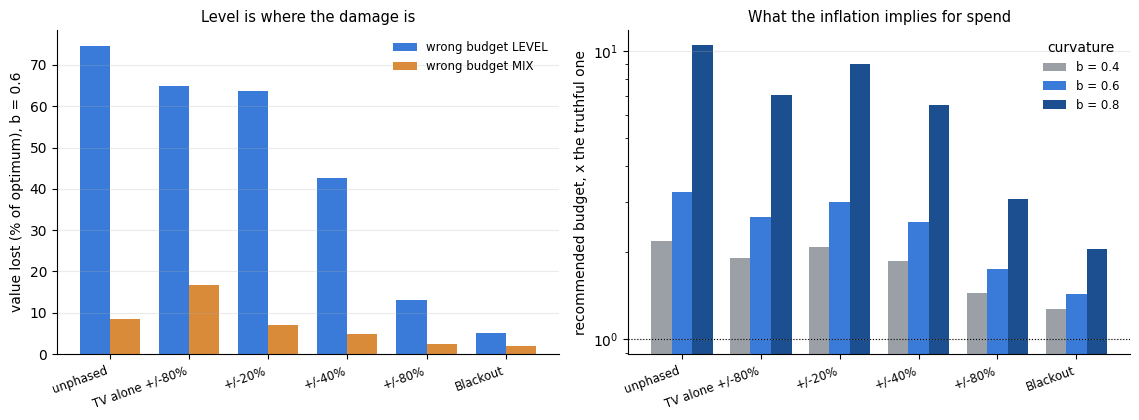

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
labels = [lab for lab, _ in MONEY_LEVERS]
x = np.arange(len(labels))

ax = axes[0]
width = 0.38
ax.bar(
    x - width / 2,
    decomposition["level_b0.6"],
    width,
    label="wrong budget LEVEL",
    color="#3a7bd9",
)
ax.bar(
    x + width / 2,
    decomposition["mix_b0.6"],
    width,
    label="wrong budget MIX",
    color="#d98b3a",
)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8.5)
ax.set_ylabel("value lost (% of optimum), b = 0.6")
ax.set_title("Level is where the damage is", fontsize=10.5)
ax.legend(fontsize=8.5, frameon=False)

ax = axes[1]
shades = {0.4: "#9aa0a6", 0.6: "#3a7bd9", 0.8: "#1b4f8f"}
w = 0.26
for i, b in enumerate(B_GRID):
    ax.bar(
        x + (i - 1) * w, client[f"budget_x_b{b}"], w, label=f"b = {b}", color=shades[b]
    )
ax.axhline(1.0, color="black", linewidth=0.8, linestyle=":")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8.5)
ax.set_yscale("log")
ax.set_ylabel("recommended budget, x the truthful one")
ax.set_title("What the inflation implies for spend", fontsize=10.5)
ax.legend(fontsize=8.5, frameon=False, title="curvature")

for a in axes:
    a.spines[["top", "right"]].set_visible(False)
    a.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

Treat this section as an illustration with its assumptions on the face of it, not as a measurement. While it was being built the headline moved three separate times under scrutiny — with a fixed budget, variance appeared to be almost all of the cost; with the level endogenous, bias overwhelmed it; and constructing an optimal baseline moved the magnitudes again and flipped the sign on `TV alone`. The bias and variance measurements in sections 1-6 did not move at all across the same work. **The statistics are findings. The money is an illustration**, and it should never be published without its assumptions beside it.

The bars are on a symmetric-log scale because the `b = 0.8` column is an order of magnitude above the others — which is itself the point. The *direction* is robust: phasing is worth more than it costs at every curvature tested. The *magnitude*, and the ranking between the levers, is not.

## 8. What four years of unphased history costs

Every measurement above fits on the plan year alone, to see the effect where it is applied. A real model is fitted on history too, and history is not phased.

In [15]:
dilution = []
for with_history in (False, True):
    for amp in (0.0, 40.0, 80.0):
        bias, _ = sweep(all_channels(amp), with_history=with_history)
        dilution.append(
            {
                "fitted_on": "4yr history + plan" if with_history else "plan year only",
                "nominal_%": amp,
                "mean_bias_%": np.mean([bias[ch] for ch in CHANNELS]),
            }
        )
print(pd.DataFrame(dilution).round(1).to_string(index=False))

         fitted_on  nominal_%  mean_bias_%
    plan year only        0.0         60.0
    plan year only       40.0         45.3
    plan year only       80.0         25.0
4yr history + plan        0.0         62.8
4yr history + plan       40.0         59.1
4yr history + plan       80.0         50.1


The gain survives but is heavily diluted — one phased year against four unphased ones is a fifth of the data, the same arithmetic notebook 03 documents for variance. Any client-facing number has to be the diluted one.

## What has to hold before any of this reaches the page

- **Bias is proportional to `baseline_cv`**, which is assumed. It stays a sensitivity band, never a single figure, unless a client supplies a proxy.
- **`demand_share = 1` throughout sections 4-8** — the maximal-coupling corner. Section 3 shows bias falls away as that relaxes, and the sweeps have not been repeated across it.
- **Section 7 measures the level effect only**, holding the split at plan proportions. Bias also distorts the *mix* whenever it is not uniform across channels, and that is not measured here — doing it properly needs a baseline plan that is already split-optimal, which the illustrative marginal returns are not.
- **One correlation level, three channels, one spend scale**, matching the gap the variance work has. Widen them together.
- **The sample is small**: 6 worlds, 40 noise draws. The large contrasts survive it; the smaller ones in sections 4 and 5 are not separated from noise at this size.